In [1]:
import pandas as pd

import snman_abm
import snman
import random
import os
import matplotlib.pyplot as plt

PROJECT = '_main'
data_directory = os.path.join('C:',os.sep,'Users','shiry', 'snman_sgProject')
export_path = os.path.join(data_directory, 'outputs', PROJECT)
inputs_path = os.path.join(data_directory, 'inputs', PROJECT)

G = snman.io.load_street_graph(
    edges_path=os.path.join(export_path, 'G_edges.gpkg'),
    nodes_path=os.path.join(export_path, 'G_nodes.gpkg'),
    crs=3414
)

nodes = list(G.nodes())

C:\Users\shiry\snman_sgProject\snman\osmnx_customized\utils.py:192: UserWarning: The `utils.config` function is deprecated and will be removed in a future release. Instead, use the `settings` module directly to configure a global setting's value. For example, `ox.settings.log_console=True`.
  warnings.warn(


In [2]:
results = []
n_runs = 20
n_agents = 150
n_steps = 100

for run in range(n_runs):
    od_pairs = []
    while len(od_pairs) < n_agents:
        origin = random.choice(nodes)
        destination = random.choice(nodes)

        if origin == destination:
            continue

        od_pairs.append((origin, destination))

    model_before = snman_abm.Network(scenario="before", n=n_agents, od_pairs=od_pairs)
    model_after = snman_abm.Network(scenario="after", n=n_agents, od_pairs=od_pairs)

    for _ in range(n_steps):
        model_before.step()
    for _ in range(n_steps):
        model_after.step()

    df_before = model_before.get_journeys()
    df_after = model_after.get_journeys()

    before_counts = df_before["mode"].value_counts(normalize=True)
    after_counts = df_after["mode"].value_counts(normalize=True)

    bike_before = before_counts.get("bike", 0)
    bike_after = after_counts.get("bike", 0)
    change = bike_after - bike_before

    results.append({
        "run": run + 1,
        "bike_before": bike_before,
        "bike_after": bike_after,
        "change": change,
    })

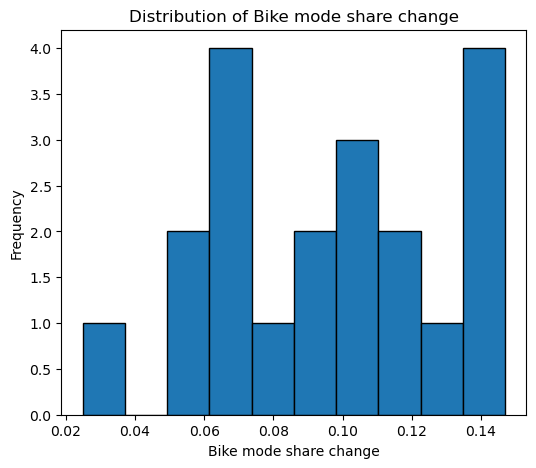

In [3]:
# plot histogram of mode share change across all the runs
results_df = pd.DataFrame(results)
plt.figure(figsize=(6, 5))
plt.hist(results_df["change"], bins=10, edgecolor="black")

plt.xlabel("Bike mode share change")
plt.ylabel("Frequency")
plt.title("Distribution of Bike mode share change")
plt.show()

In [8]:
mean_before = results_df["bike_before"].mean()
mean_after = results_df["bike_after"].mean()
std_before = results_df["bike_before"].std()
std_after = results_df["bike_after"].std()

print("Mean change:", results_df["change"].mean())
print("Std dev:", results_df["change"].std())
print("Min change:", results_df["change"].min())
print("Max change:", results_df["change"].max())

Mean change: 0.09583971771056801
Std dev: 0.03387568759375892
Min change: 0.02478900409934895
Max change: 0.14707515734912993


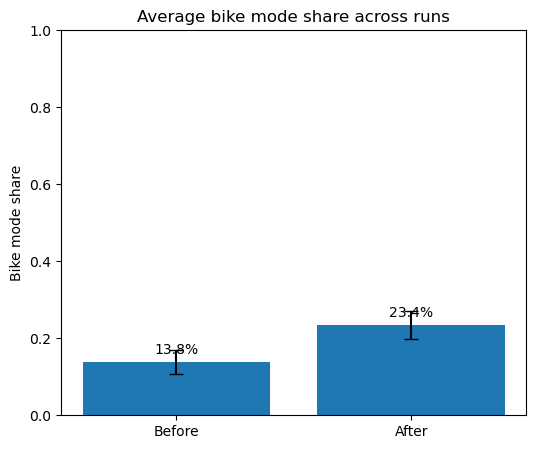

In [7]:
# plot avg bike mode share before and after, across runs
labels = ["Before", "After"]
means = [mean_before, mean_after]
errors = [std_before, std_after]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, means, yerr=errors, capsize=5)

plt.ylabel("Bike mode share")
plt.title("Average bike mode share across runs")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height*100:.1f}%",
        ha="center"
    )

plt.show()